# Mutation Bias Analysis — Figures

Generates all figures for the 14-species mutation bias analysis.
Data are loaded from CSV files produced by `Multi_species_analysis_14sp.ipynb`.

All figures are saved to `figures/`.

In [8]:
# Setup — imports, paths, and shared species colour palette
# Genus groupings and colour assignments are defined once here and reused across all figures.
#
# matplotlib subplots: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
# seaborn barplot: https://seaborn.pydata.org/generated/seaborn.barplot.html
# scipy.stats linregress: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html
# adjustText: https://github.com/Phlya/adjustText

import math
import os
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

subprocess.run(["pip", "install", "adjustText", "-q"], check=True)
from adjustText import adjust_text

os.makedirs("/home/jovyan/shared-team/2025-masters-project/people/alison/figures", exist_ok=True)

BASE = "/home/jovyan/shared-team/2025-masters-project/people/alison"

# ── Genus groupings ───────────────────────────────────────────────────────────
genus_groups = {
    "Bordetella":     ["B. pertussis"],
    "Campylobacter":  ["C. jejuni"],
    "Escherichia":    ["E. coli"],
    "Haemophilus":    ["H. influenzae"],
    "Klebsiella":     ["K. pneumoniae"],
    "Listeria":       ["L. monocytogenes"],
    "Mycobacterium":  ["M. tuberculosis"],
    "Neisseria":      ["N. meningitidis"],
    "Pseudomonas":    ["P. aeruginosa"],
    "Salmonella":     ["S. typhimurium"],
    "Staphylococcus": ["S. aureus", "S. epidermidis"],
    "Streptococcus":  ["S. agalactiae", "S. pneumoniae"],
}

GENUS_COLORMAPS = {
    "Bordetella":     "PuBu",
    "Campylobacter":  "winter",
    "Escherichia":    "GnBu",
    "Haemophilus":    "Reds",
    "Klebsiella":     "Blues",
    "Listeria":       "Greys",
    "Mycobacterium":  "spring",
    "Neisseria":      "PuRd",
    "Pseudomonas":    "cool",
    "Salmonella":     "YlGn",
    "Staphylococcus": "OrRd",
    "Streptococcus":  "RdPu",
}

species_colours = {}
for genus, species_list in genus_groups.items():
    cmap      = mpl.colormaps[GENUS_COLORMAPS[genus]]
    positions = np.linspace(0.4, 0.75, len(species_list))
    if genus == "Staphylococcus":
        positions = np.linspace(0.55, 0.85, len(species_list))
    for sp, pos in zip(species_list, positions):
        species_colours[sp] = cmap(pos)

species_order = [sp for sps in genus_groups.values() for sp in sps]

# ── Ecological niche metadata ─────────────────────────────────────────────────
niche = {
    "C. jejuni":        "Gut",
    "E. coli":          "Gut",
    "S. typhimurium":   "Gut",
    "S. agalactiae":    "Gut",
    "B. pertussis":     "Respiratory",
    "H. influenzae":    "Respiratory",
    "N. meningitidis":  "Respiratory",
    "S. pneumoniae":    "Respiratory",
    "K. pneumoniae":    "Environmental/Soil",
    "L. monocytogenes": "Environmental/Soil",
    "P. aeruginosa":    "Environmental/Soil",
    "M. tuberculosis":  "Host (intracellular)",
    "S. aureus":        "Skin/mucosal",
    "S. epidermidis":   "Skin/mucosal",
}

niche_colours = {
    "Gut":                  "#E8735A",
    "Respiratory":          "#6B9BD2",
    "Environmental/Soil":   "#7BC67E",
    "Host (intracellular)": "#B07EC4",
    "Skin/mucosal":         "#F4A460",
}

niche_order = ["Gut", "Respiratory", "Environmental/Soil", "Host (intracellular)", "Skin/mucosal"]

print("Setup complete.")

Setup complete.


---
## Opportunity-normalised six-class mutation spectrum

Bars show the opportunity-normalised rate for each of the six pyrimidine-convention
substitution classes per species, grouped by genus. Rates are computed as total
mutation count divided by the number of available sites on both strands.
Y-axes are free per panel so spectral shape of each species can be seen.

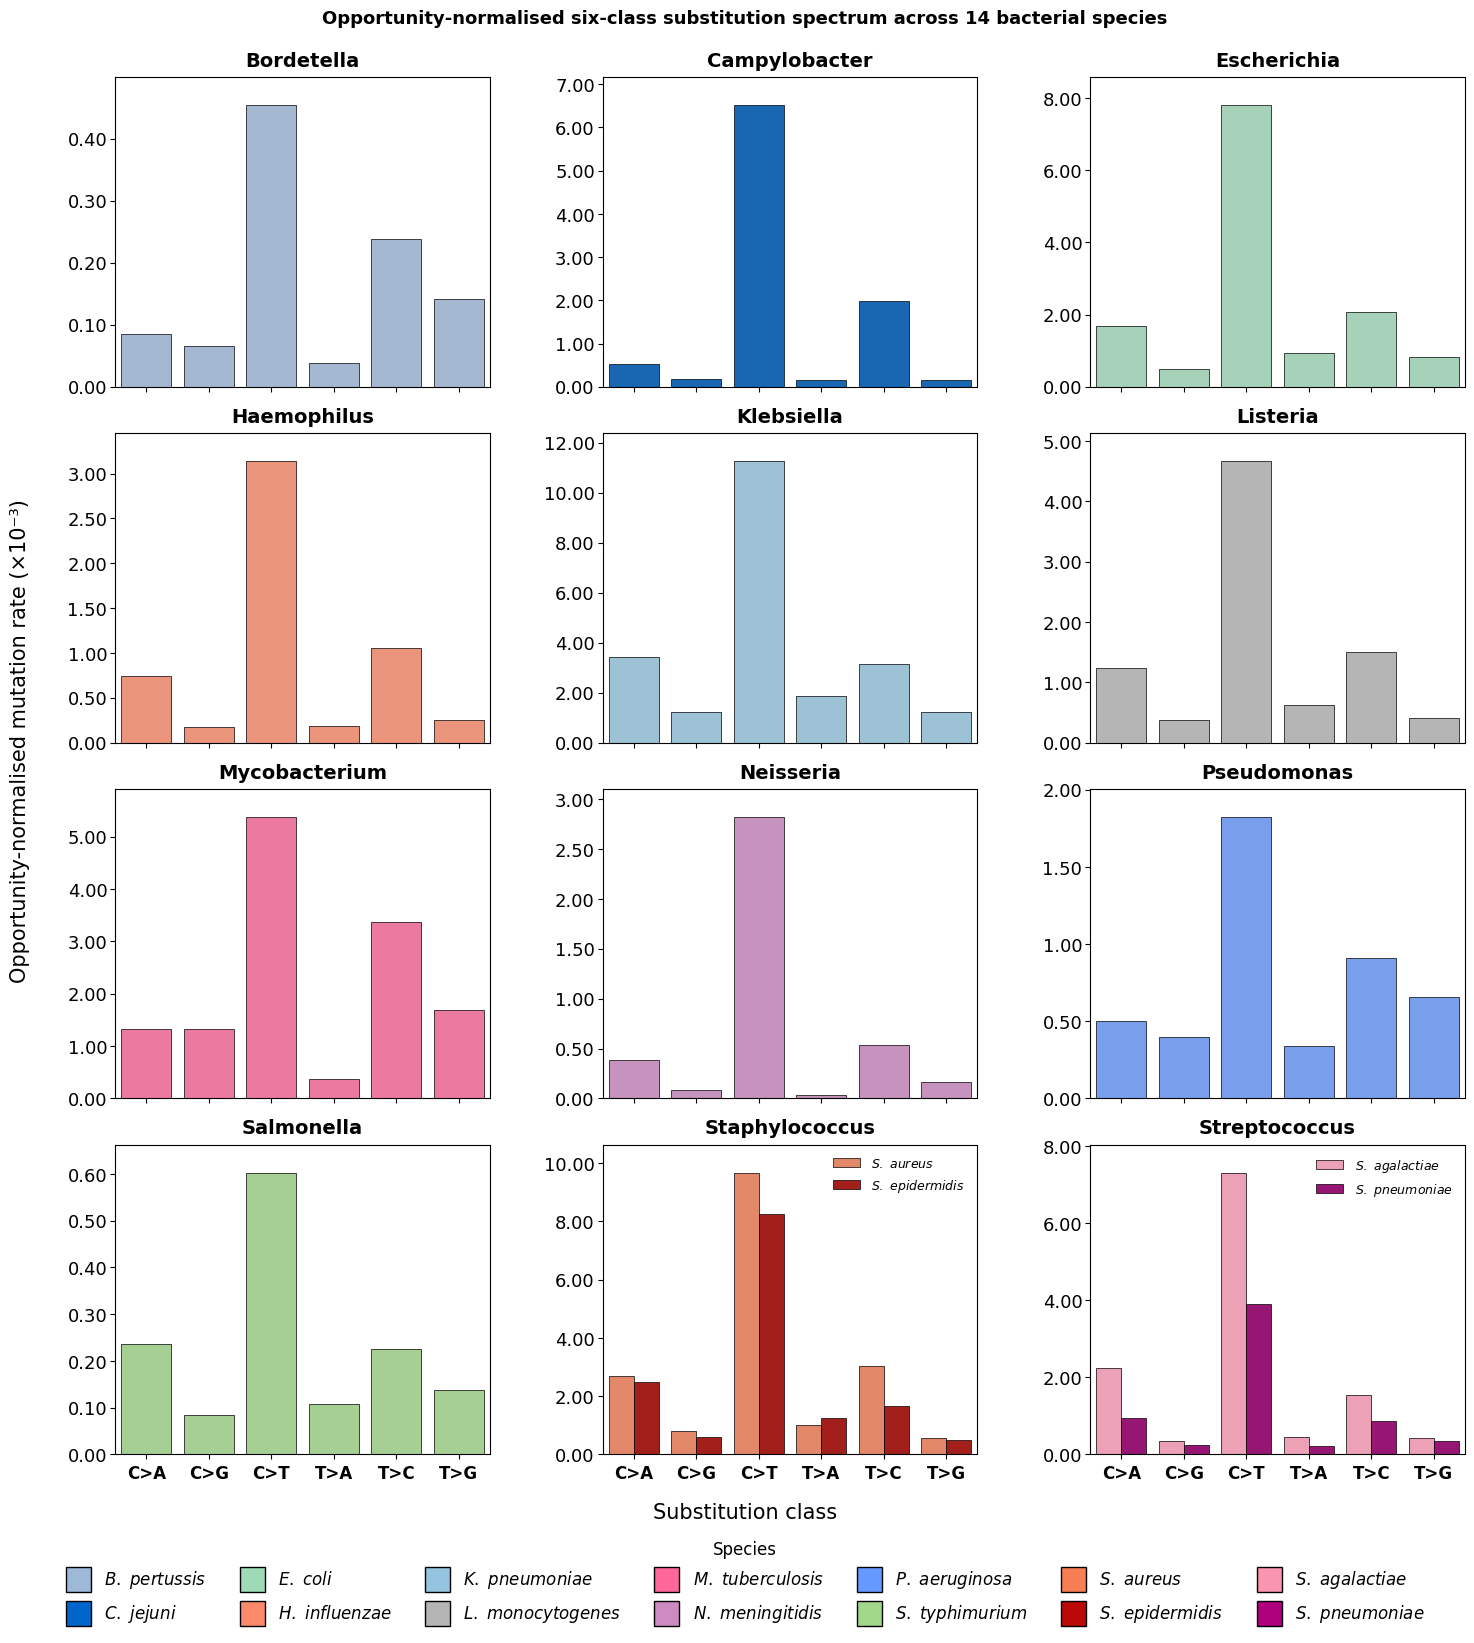

Saved: 14species_6class_spectrum.png


In [10]:
# Opportunity-normalised six-class mutation spectrum (per genus)
# seaborn barplot: https://seaborn.pydata.org/generated/seaborn.barplot.html
# matplotlib FuncFormatter: https://matplotlib.org/stable/api/ticker_api.html#matplotlib.ticker.FuncFormatter

df = pd.read_csv(f"{BASE}/mutation_data_14sp.csv")

# ── Compute opportunity-normalised rates ──────────────────────────────────────
mut_labels = ["C>A", "C>G", "C>T", "T>A", "T>C", "T>G"]

spectrum = (
    df.groupby(["species", "mut_class"])
    .agg(n_mut=("n_mut", "sum"), opp=("opp", "first"))
    .reset_index()
)
spectrum["rate"]      = spectrum["n_mut"] / spectrum["opp"]
spectrum["mut_label"] = spectrum["mut_class"].str.replace("->", ">")

# ── Plot ──────────────────────────────────────────────────────────────────────
genus_list = list(genus_groups.keys())
ncols      = 3
nrows      = math.ceil(len(genus_list) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 17), sharey=False)
fig.subplots_adjust(hspace=0.15, wspace=0.3, top=0.94, bottom=0.13,
                    left=0.08, right=0.98)
axes = axes.flatten()

for i, genus in enumerate(genus_list):
    ax           = axes[i]
    species_list = genus_groups[genus]
    row          = i // ncols
    is_bottom    = (row == nrows - 1)

    sub = spectrum[spectrum["species"].isin(species_list)].copy()
    sub["mut_label"] = pd.Categorical(sub["mut_label"],
                                      categories=mut_labels, ordered=True)

    sns.barplot(
        data=sub,
        x="mut_label",
        y="rate",
        hue="species",
        order=mut_labels,
        hue_order=species_list,
        palette={sp: species_colours[sp] for sp in species_list},
        ax=ax,
        dodge=True,
        edgecolor="black",
        linewidth=0.5,
    )

    ax.set_title(genus, fontsize=14, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")

    y_max_panel = sub["rate"].max() * 1.1
    ax.set_ylim(0, y_max_panel)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda val, _: f"{val*1000:.2f}")
    )
    ax.tick_params(axis="y", labelsize=13, pad=2)

    if is_bottom:
        ax.tick_params(axis="x", labelsize=12)
        for label in ax.get_xticklabels():
            label.set_fontweight("bold")
    else:
        ax.tick_params(axis="x", labelbottom=False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("black")

    legend = ax.get_legend()
    if legend is not None:
        if len(species_list) == 1:
            legend.remove()
        else:
            legend.set_title("")
            for text in legend.get_texts():
                text.set_fontsize(9)
                sp_name = text.get_text()
                text.set_text("$\\it{" + sp_name.replace(" ", "\\ ") + "}$")
            legend.get_frame().set_visible(False)

for ax in axes[len(genus_list):]:
    ax.set_visible(False)

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(facecolor=species_colours[sp], edgecolor="black",
                   label="$\\it{" + sp.replace(" ", "\\ ") + "}$")
    for genus in genus_list
    for sp in genus_groups[genus]
]
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.02),
    frameon=False,
    title="Species",
    title_fontsize=12,
    fontsize=12,
    handleheight=2.0,
    handlelength=1.5,
    ncol=7,
)

fig.supylabel("Opportunity-normalised mutation rate (×10⁻³)", fontsize=15,
              x=0.01, y=0.55)
fig.supxlabel("Substitution class", fontsize=15, y=0.09)
fig.suptitle(
    "Opportunity-normalised six-class substitution spectrum across 14 bacterial species",
    fontsize=13, fontweight="bold"
)

plt.savefig(f"{BASE}/figures/14species_6class_spectrum.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 14species_6class_spectrum.png")

---
## dN/dS ratio

Opportunity-normalised dN/dS ratio per species. dN and dS are calculated by
dividing nonsynonymous and synonymous mutation counts by their respective
mutational opportunity denominators (from codon enumeration). The dashed line
at 1.0 indicates the neutral expectation.

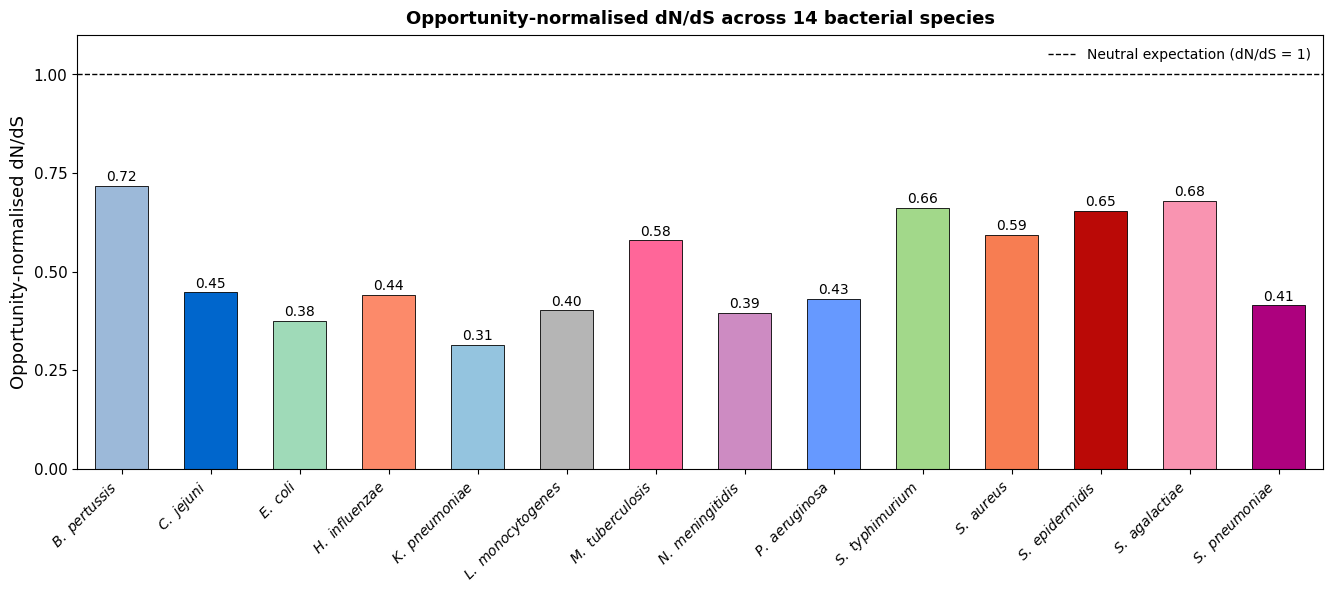

Saved: 14species_dNdS.png


In [11]:
# dN/dS ratio — opportunity-normalised per species
# matplotlib bar: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html

df_opp = pd.read_csv(f"{BASE}/mutation_data_category_opp.csv")

# ── Calculate opportunity-normalised dN/dS ────────────────────────────────────
results = []
for sp in species_order:
    sp_df      = df_opp[df_opp["species"] == sp]
    syn_row    = sp_df[sp_df["category"] == "synonymous"].iloc[0]
    nonsyn_row = sp_df[sp_df["category"] == "nonsynonymous"].iloc[0]
    dS         = syn_row["n_mut"]    / syn_row["opp"]    if syn_row["opp"]    > 0 else np.nan
    dN         = nonsyn_row["n_mut"] / nonsyn_row["opp"] if nonsyn_row["opp"] > 0 else np.nan
    dn_ds      = dN / dS if dS > 0 else np.nan
    results.append({"species": sp, "dn_ds": dn_ds})

ratio_df = pd.DataFrame(results)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
fig.subplots_adjust(top=0.90, bottom=0.28, left=0.08, right=0.97)

x       = np.arange(len(ratio_df))
colours = [species_colours[sp] for sp in ratio_df["species"]]

bars = ax.bar(x, ratio_df["dn_ds"], color=colours, edgecolor="black",
              linewidth=0.6, width=0.6)

for bar, val in zip(bars, ratio_df["dn_ds"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.2f}",
            ha="center", va="bottom", fontsize=10)

ax.axhline(1.0, color="black", linewidth=1.0, linestyle="--",
           zorder=5, label="Neutral expectation (dN/dS = 1)")

ax.set_xticks(x)
italic_labels = [r"$\it{" + sp.replace(" ", r"\ ") + r"}$"
                 for sp in ratio_df["species"]]
ax.set_xticklabels(italic_labels, rotation=45, ha="right", fontsize=10)
ax.set_xlim(-0.5, len(ratio_df) - 0.5)
ax.set_ylim(0, max(ratio_df["dn_ds"].max() * 1.15, 1.1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.2f}"))
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.tick_params(axis="y", labelsize=11)
ax.set_ylabel("Opportunity-normalised dN/dS", fontsize=13)
ax.set_title("Opportunity-normalised dN/dS across 14 bacterial species",
             fontsize=13, fontweight="bold", pad=8)
ax.legend(fontsize=10, frameon=False, loc="upper right")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)

plt.savefig(f"{BASE}/figures/14species_dNdS.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 14species_dNdS.png")

---
## Ts/Tv ratio by host lifestyle and ecological niche

Two-panel figure. Panel A shows Ts/Tv ratio per species ordered by value,
with hatching indicating obligate vs facultative host association.
Panel B shows the same values as a strip plot grouped by primary ecological
niche, with dashed lines marking the group mean.

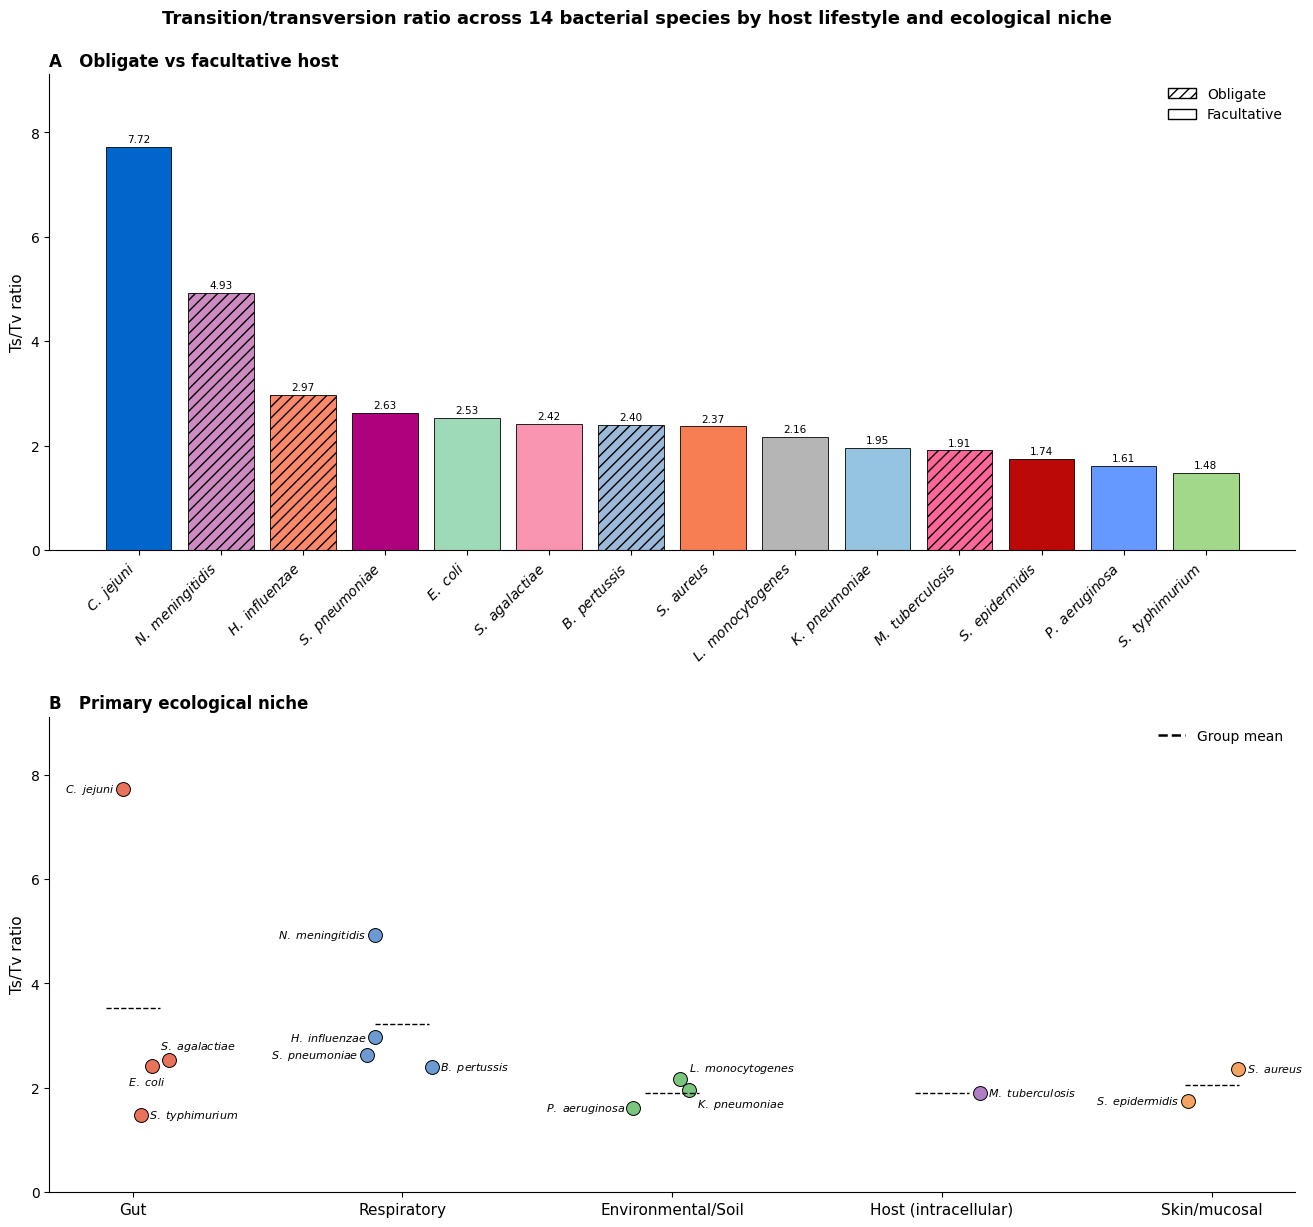

Saved: 14species_TsTv_twopanel.png


In [ ]:
# Ts/Tv ratio — two-panel figure by host lifestyle and ecological niche
# matplotlib gridspec: https://matplotlib.org/stable/api/_as_gen/matplotlib.gridspec.GridSpec.html
# numpy random jitter: https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html

df = pd.read_csv(f"{BASE}/mutation_data_14sp.csv")

# ── Ts/Tv per species ─────────────────────────────────────────────────────────
transitions   = ["C->T", "T->C"]
transversions = ["C->A", "C->G", "T->A", "T->G"]

ts   = df[df["mut_class"].isin(transitions)].groupby("species")["n_mut"].sum().reset_index().rename(columns={"n_mut": "ts"})
tv   = df[df["mut_class"].isin(transversions)].groupby("species")["n_mut"].sum().reset_index().rename(columns={"n_mut": "tv"})
tstv = ts.merge(tv, on="species")
tstv["tstv"] = tstv["ts"] / tstv["tv"]

obligate_facultative = {
    "B. pertussis":     "Obligate",
    "C. jejuni":        "Facultative",
    "E. coli":          "Facultative",
    "H. influenzae":    "Obligate",
    "K. pneumoniae":    "Facultative",
    "L. monocytogenes": "Facultative",
    "M. tuberculosis":  "Obligate",
    "N. meningitidis":  "Obligate",
    "P. aeruginosa":    "Facultative",
    "S. typhimurium":   "Facultative",
    "S. aureus":        "Facultative",
    "S. epidermidis":   "Facultative",
    "S. agalactiae":    "Facultative",
    "S. pneumoniae":    "Facultative",
}

oblig_hatches = {"Obligate": "///", "Facultative": ""}

tstv["oblig"]  = tstv["species"].map(obligate_facultative)
tstv["niche"]  = tstv["species"].map(niche)
tstv["colour"] = tstv["species"].map(species_colours)
tstv = tstv.sort_values("tstv", ascending=False).reset_index(drop=True)
sp_order = tstv["species"].tolist()

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 13))
gs  = gridspec.GridSpec(2, 1, height_ratios=[1, 1],
                        left=0.08, right=0.97,
                        top=0.94, bottom=0.08,
                        hspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── Panel A — bar chart ───────────────────────────────────────────────────────
x = np.arange(len(sp_order))
for j, sp in enumerate(sp_order):
    val    = tstv.loc[tstv["species"] == sp, "tstv"].values[0]
    colour = species_colours[sp]
    hatch  = oblig_hatches[obligate_facultative[sp]]
    ax1.bar(j, val, color=colour, hatch=hatch,
            edgecolor="black", linewidth=0.6)
    ax1.text(j, val + 0.05, f"{val:.2f}",
             ha="center", va="bottom", fontsize=7.5)

italic_labels = ["$\\it{" + sp.replace(" ", "\\ ") + "}$" for sp in sp_order]
ax1.set_xticks(x)
ax1.set_xticklabels(italic_labels, rotation=45, ha="right", fontsize=10)
ax1.set_ylabel("Ts/Tv ratio", fontsize=11)
ax1.set_ylim(0, tstv["tstv"].max() * 1.18)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_title("A   Obligate vs facultative host", fontsize=12,
              fontweight="bold", loc="left")

legend_handles_a = [
    mpatches.Patch(facecolor="white", edgecolor="black", hatch=h, label=l)
    for l, h in oblig_hatches.items()
]
ax1.legend(handles=legend_handles_a, fontsize=10, frameon=False,
           loc="upper right")

# ── Panel B — strip plot ──────────────────────────────────────────────────────
np.random.seed(42)
for i, niche_cat in enumerate(niche_order):
    species_in_niche = tstv[tstv["niche"] == niche_cat].copy()
    n      = len(species_in_niche)
    jitter = np.random.uniform(-0.15, 0.15, n)

    manual_offsets = {
        "E. coli":          (-3, -15),
        "S. agalactiae":    (6,   14),
        "K. pneumoniae":    (6,  -10),
        "L. monocytogenes": (6,    8),
        "M. tuberculosis":  (6,    0),
    }

    for j, (_, row) in enumerate(species_in_niche.iterrows()):
        xp = i + jitter[j]
        yp = row["tstv"]
        ax2.scatter(xp, yp, color=niche_colours[niche_cat],
                    s=100, edgecolors="black", linewidth=0.7, zorder=3)
        if row["species"] in manual_offsets:
            xoff, yoff = manual_offsets[row["species"]]
            ha = "left" if xoff >= 0 else "right"
        else:
            ha   = "left" if jitter[j] >= 0 else "right"
            xoff = 6 if jitter[j] >= 0 else -6
            yoff = 0
        ax2.annotate(
            "$\\it{" + row["species"].replace(" ", "\\ ") + "}$",
            xy=(xp, yp),
            xytext=(xoff, yoff),
            textcoords="offset points",
            fontsize=8, va="center", ha=ha,
        )

    mean_val = species_in_niche["tstv"].mean()
    ax2.plot([i - 0.1, i + 0.1], [mean_val, mean_val],
             color="black", linewidth=1, linestyle="--", zorder=4)

ax2.set_xticks(range(len(niche_order)))
ax2.set_xticklabels(niche_order, fontsize=11)
ax2.set_ylabel("Ts/Tv ratio", fontsize=11)
ax2.set_ylim(0, tstv["tstv"].max() * 1.18)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.set_title("B   Primary ecological niche", fontsize=12,
              fontweight="bold", loc="left")

ax2.plot([], [], color="black", linewidth=1.8,
         linestyle="--", label="Group mean")
ax2.legend(fontsize=10, frameon=False, loc="upper right")

fig.suptitle(
    "Transition/transversion ratio across 14 bacterial species by host lifestyle and ecological niche",
    fontsize=13, fontweight="bold", y=0.99
)

plt.savefig(f"{BASE}/figures/14species_TsTv_twopanel.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 14species_TsTv_twopanel.png")

---
## Trinucleotide context spectrum

Opportunity-normalised mutation rate across all 96 trinucleotide contexts
(COSMIC convention), grouped by genus. Contexts are ordered by substitution
class (C>A, C>G, C>T, T>A, T>C, T>G) with 16 contexts per class. Dashed
vertical lines separate substitution classes. Y-axes are free per panel.
Substitution class labels are shown on the top row only; context labels on
the bottom row only.

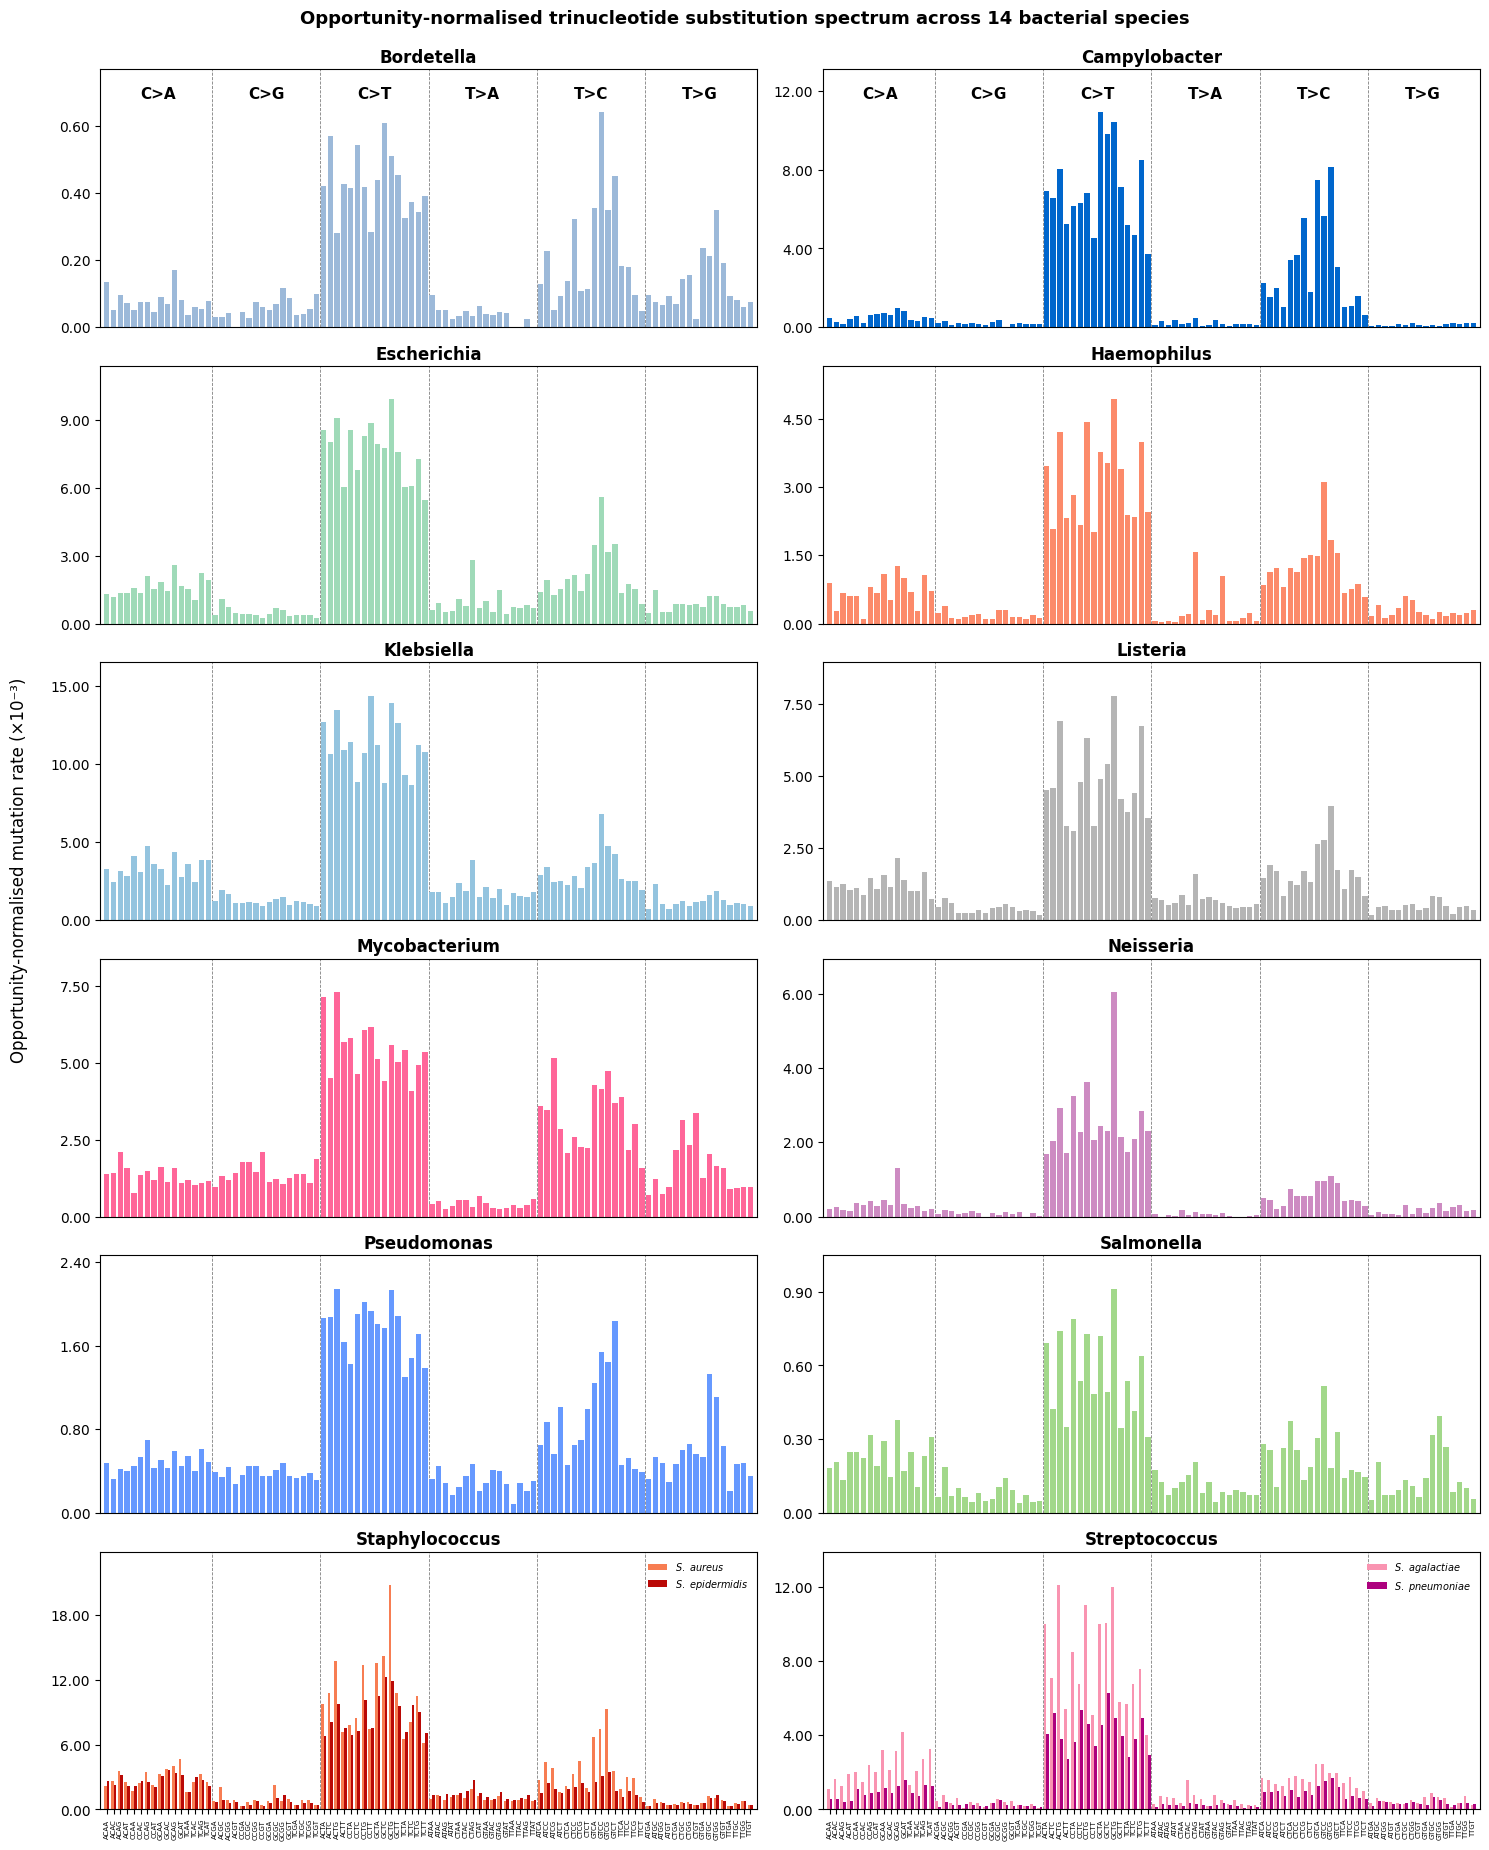

Saved: 14species_trinucleotide_spectrum.png


In [13]:
# Trinucleotide context spectrum — 96-class COSMIC convention, per genus
# 96-context ordering follows: Alexandrov et al. (2013) Nature, 500, 415-421.
#   https://doi.org/10.1038/nature12477

df_tri = pd.read_csv(f"{BASE}/trinucleotide_data_14sp.csv")

# ── Context order ─────────────────────────────────────────────────────────────
mut_types  = ["C>A", "C>G", "C>T", "T>A", "T>C", "T>G"]
bases_tri  = ["A", "C", "G", "T"]
contexts   = [f"{l}[{m}]{r}" for m in mut_types for l in bases_tri for r in bases_tri]
n_ctx      = len(contexts)
x          = np.arange(n_ctx)
group_size = 16
dividers   = [group_size * i - 0.5 for i in range(1, 6)]

# ── Plot ──────────────────────────────────────────────────────────────────────
genus_list = list(genus_groups.keys())
ncols      = 2
nrows      = 6

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 20), sharey=False)
fig.subplots_adjust(hspace=0.15, wspace=0.1, top=0.95, bottom=0.08,
                    left=0.07, right=0.99)
axes = axes.flatten()

for i, genus in enumerate(genus_list):
    ax           = axes[i]
    species_list = genus_groups[genus]
    row          = i // ncols
    is_top       = (row == 0)
    is_bottom    = (row == nrows - 1)
    n_sp         = len(species_list)
    bar_width    = 0.8 / n_sp

    all_vals = []
    for sp in species_list:
        sp_data = df_tri[df_tri["species"] == sp].set_index("context")
        for ctx in contexts:
            if ctx in sp_data.index and sp_data.loc[ctx, "opp"] > 0:
                all_vals.append(sp_data.loc[ctx, "n_mut"] / sp_data.loc[ctx, "opp"])
    max_val = max(all_vals) if all_vals else 0.001

    for j, sp in enumerate(species_list):
        sp_data = df_tri[df_tri["species"] == sp].set_index("context")
        props   = [sp_data.loc[ctx, "n_mut"] / sp_data.loc[ctx, "opp"]
                   if ctx in sp_data.index and sp_data.loc[ctx, "opp"] > 0 else 0
                   for ctx in contexts]
        offset  = x + (j - (n_sp - 1) / 2) * bar_width
        ax.bar(offset, props, width=bar_width,
               color=species_colours[sp], linewidth=0, label=sp)

    for xd in dividers:
        ax.axvline(x=xd, color="grey", linestyle="--", linewidth=0.6, zorder=0)

    if is_top:
        for k, mut in enumerate(mut_types):
            mid = group_size * k + group_size / 2 - 0.5
            ax.text(mid, max_val * 1.05, mut,
                    ha="center", va="bottom", fontsize=11,
                    fontweight="bold", color="black")

    ax.set_title(genus, fontsize=12, fontweight="bold", pad=5)
    ax.set_xlim(-1, n_ctx)
    ax.set_ylim(0, max_val * 1.20 if is_top else max_val * 1.15)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda val, _: f"{val*1000:.2f}")
    )
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax.tick_params(axis="y", labelsize=10)

    if is_bottom:
        ax.set_xticks(x)
        ax.set_xticklabels(
            [ctx.replace("[", "").replace("]", "").replace(">", "")
             for ctx in contexts],
            rotation=90, fontsize=5, ha="center",
        )
    else:
        ax.tick_params(axis="x", labelbottom=False)
        ax.set_xticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

    if n_sp > 1:
        legend = ax.legend(fontsize=7, frameon=False, loc="upper right")
        for text in legend.get_texts():
            sp_name = text.get_text()
            text.set_text("$\\it{" + sp_name.replace(" ", "\\ ") + "}$")

for ax in axes[len(genus_list):]:
    ax.set_visible(False)

fig.text(0.01, 0.55, "Opportunity-normalised mutation rate (×10⁻³)",
         va="center", rotation="vertical", fontsize=12)
fig.suptitle(
    "Opportunity-normalised trinucleotide substitution spectrum across 14 bacterial species",
    fontsize=13, fontweight="bold"
)

plt.savefig(f"{BASE}/figures/14species_trinucleotide_spectrum.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 14species_trinucleotide_spectrum.png")

---
## GC content vs C→T mutation rate

Four-panel scatter plot of genomic GC content against opportunity-normalised
C→T mutation rate, shown separately for overall, synonymous, non-synonymous,
and intergenic mutations. Y-axes are log-scaled. Dashed lines show log-linear
regression fits; r and p values are from Pearson correlation on log-transformed
rates.

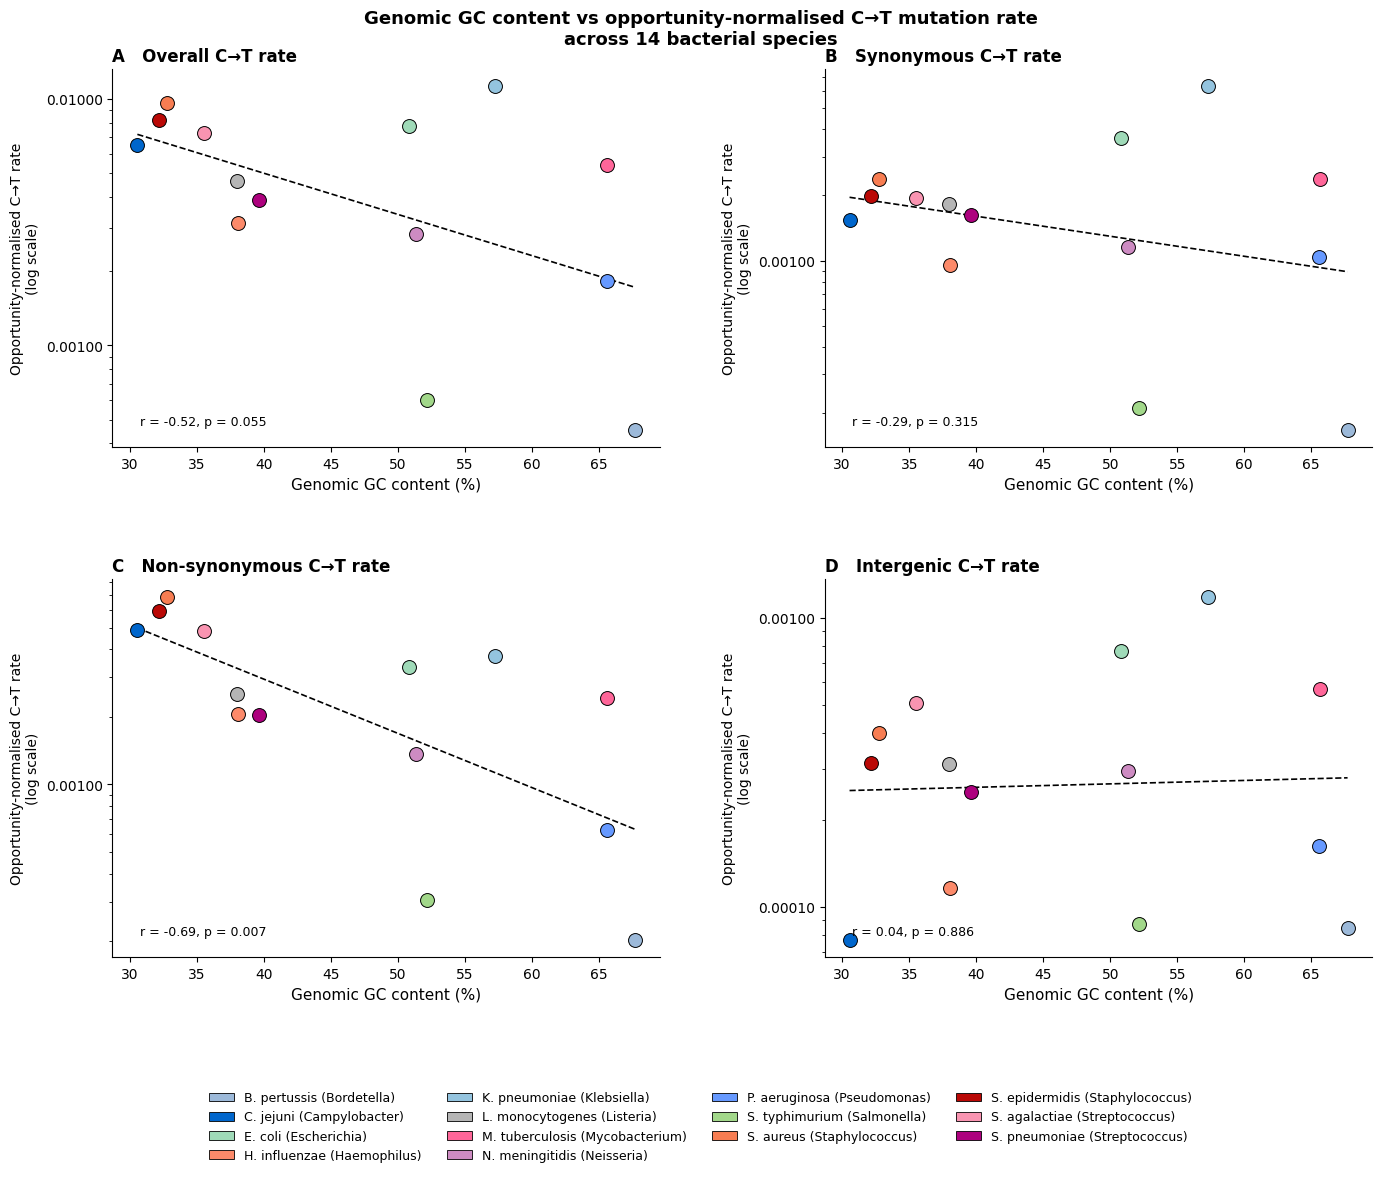

Saved: 14species_GC_CT_scatter.png


In [14]:
# GC content vs C→T mutation rate — 2×2 scatter plot with log-linear regression
# scipy.stats.linregress: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html

gc_data  = pd.read_csv(f"{BASE}/gc_content_14sp.csv")
mut_data = pd.read_csv(f"{BASE}/mutation_data_14sp.csv")

# ── C→T rates per category ────────────────────────────────────────────────────
def get_ct_rate(data, category=None):
    mask = data["mut_class"] == "C->T"
    if category:
        mask &= data["category"] == category
    ct = (
        data[mask]
        .groupby("species")
        .agg(n_mut=("n_mut", "sum"), opp=("opp", "first"))
        .reset_index()
    )
    ct["rate"] = ct["n_mut"] / ct["opp"]
    return ct.merge(gc_data, on="species")

overall_ct = get_ct_rate(mut_data)
syn_ct     = get_ct_rate(mut_data, "synonymous")
nonsyn_ct  = get_ct_rate(mut_data, "nonsynonymous")
igr_ct     = get_ct_rate(mut_data, "intergenic")

# ── Legend handles ────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=species_colours[sp],
                   edgecolor="black", linewidth=0.6,
                   label=f"{sp} ({genus})")
    for genus, sps in genus_groups.items()
    for sp in sps
]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.subplots_adjust(hspace=0.35, wspace=0.3,
                    top=0.92, bottom=0.18, left=0.08, right=0.98)

datasets = [
    (overall_ct, "A   Overall C→T rate",       axes[0, 0]),
    (syn_ct,     "B   Synonymous C→T rate",     axes[0, 1]),
    (nonsyn_ct,  "C   Non-synonymous C→T rate", axes[1, 0]),
    (igr_ct,     "D   Intergenic C→T rate",     axes[1, 1]),
]

for data, panel_title, ax in datasets:
    for _, row in data.iterrows():
        sp = row["species"]
        ax.scatter(row["gc_content"], row["rate"],
                   color=species_colours.get(sp, "black"),
                   s=100, edgecolors="black", linewidth=0.7, zorder=3)

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.5f}"))

    log_rate = np.log(data["rate"])
    slope, intercept, r, p, se = stats.linregress(data["gc_content"], log_rate)
    x_line = np.linspace(data["gc_content"].min(), data["gc_content"].max(), 200)
    y_line = np.exp(slope * x_line + intercept)
    ax.plot(x_line, y_line, color="black", linestyle="--", linewidth=1.2, zorder=2)
    ax.text(0.05, 0.05, f"r = {r:.2f}, p = {p:.3f}",
            transform=ax.transAxes, fontsize=9, va="bottom")

    ax.set_xlabel("Genomic GC content (%)", fontsize=11)
    ax.set_ylabel("Opportunity-normalised C→T rate\n(log scale)", fontsize=10)
    ax.set_title(panel_title, fontsize=12, fontweight="bold", loc="left")
    ax.tick_params(labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Genomic GC content vs opportunity-normalised C→T mutation rate\nacross 14 bacterial species",
    fontsize=13, fontweight="bold", y=0.97
)

fig.legend(handles=legend_handles, loc="lower center", ncol=4,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, 0.0))

plt.savefig(f"{BASE}/figures/14species_GC_CT_scatter.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 14species_GC_CT_scatter.png")

---
## Proportion of mutations by functional category

Three-panel bar chart showing the proportion of total mutations falling in
each functional category (synonymous, non-synonymous, intergenic) per species.
Y-axis is shared across panels. Species order follows genus groupings consistent
with other figures.

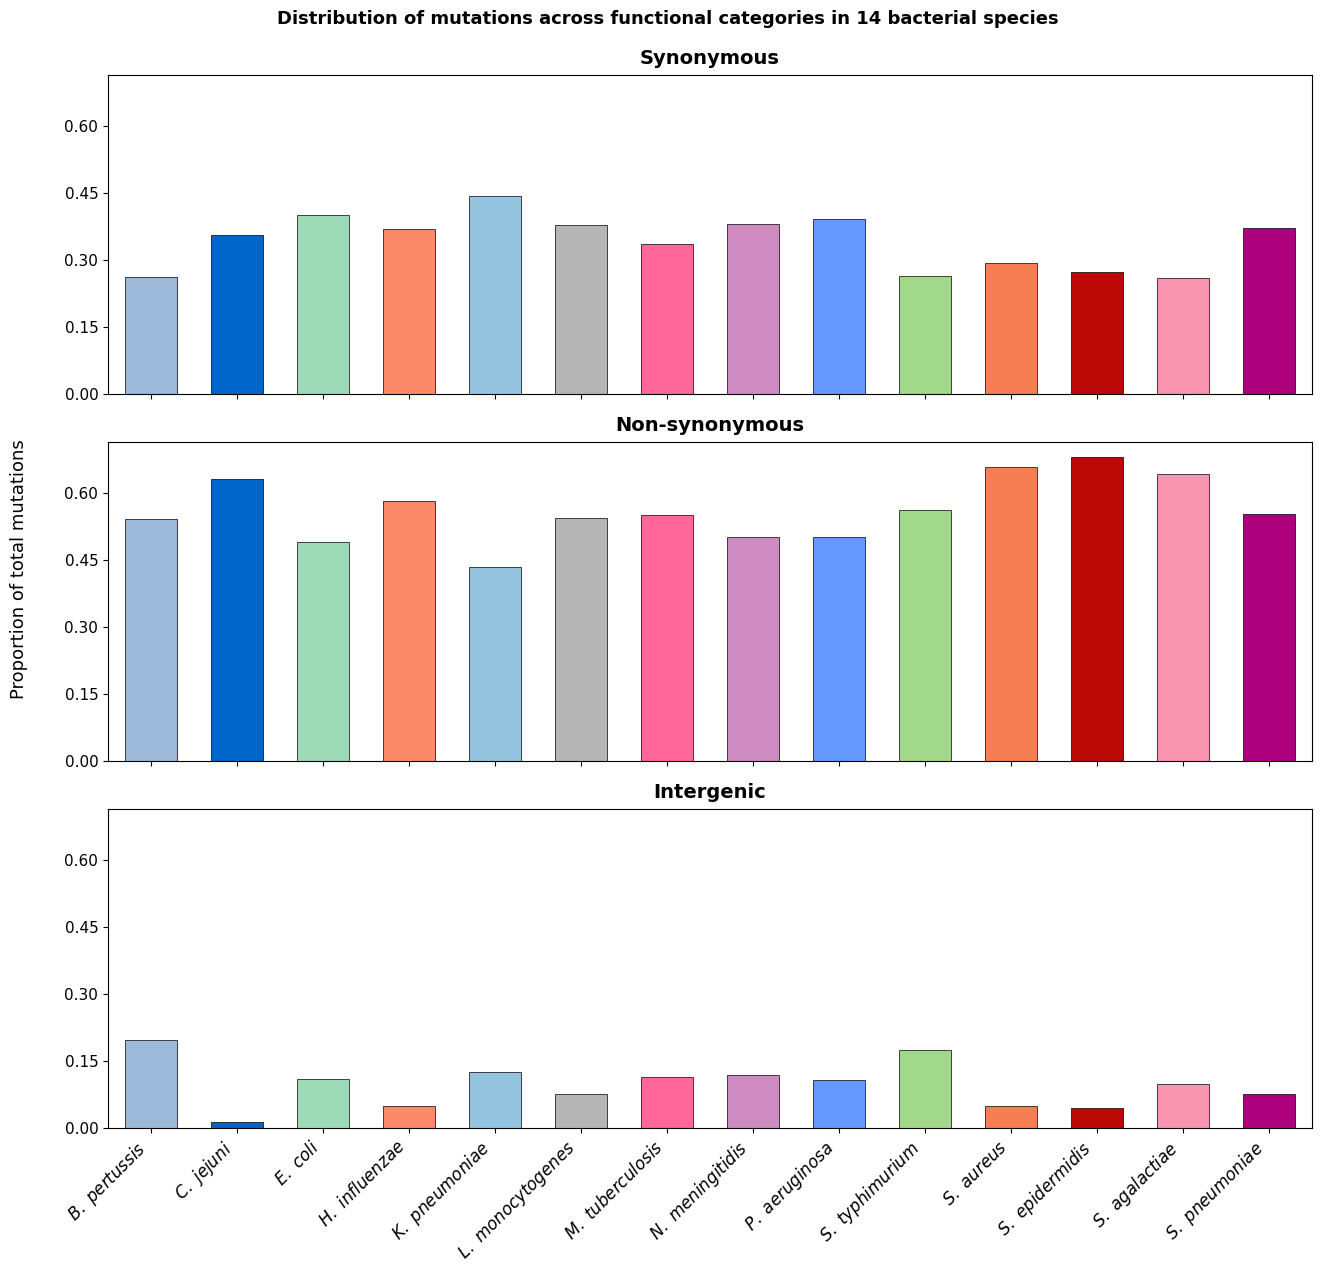

Saved: 14species_category_proportions.png


In [15]:
# Proportion of mutations by functional category — three-panel bar chart

df = pd.read_csv(f"{BASE}/mutation_data_14sp.csv")

# ── Compute proportions ───────────────────────────────────────────────────────
total = (
    df.groupby("species")["n_mut"].sum().reset_index()
    .rename(columns={"n_mut": "total"})
)
cat_counts = df.groupby(["species", "category"])["n_mut"].sum().reset_index()
cat_counts = cat_counts.merge(total, on="species")
cat_counts["proportion"] = cat_counts["n_mut"] / cat_counts["total"]

# ── Plot ──────────────────────────────────────────────────────────────────────
categories = ["synonymous", "nonsynonymous", "intergenic"]
cat_titles  = ["Synonymous", "Non-synonymous", "Intergenic"]

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharey=True)
fig.subplots_adjust(hspace=0.15, top=0.93, bottom=0.12, left=0.1, right=0.96)

x = np.arange(len(species_order))

for i, (ax, cat, title) in enumerate(zip(axes, categories, cat_titles)):
    sub = cat_counts[cat_counts["category"] == cat].set_index("species")
    proportions = [
        sub.loc[sp, "proportion"] if sp in sub.index else 0
        for sp in species_order
    ]
    colours = [species_colours[sp] for sp in species_order]
    ax.bar(x, proportions, color=colours, edgecolor="black",
           linewidth=0.5, width=0.6)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=8)
    ax.set_xlim(-0.5, len(species_order) - 0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.2f}"))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    ax.tick_params(axis="y", labelsize=11)
    ax.set_xticks(x)

    if i == 2:
        italic_labels = ["$\\it{" + sp.replace(" ", "\\ ") + "}$"
                         for sp in species_order]
        ax.set_xticklabels(italic_labels, rotation=45, ha="right", fontsize=12)
    else:
        ax.tick_params(axis="x", labelbottom=False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color("black")

fig.text(0.03, 0.55, "Proportion of total mutations",
         va="center", rotation="vertical", fontsize=13)
fig.suptitle(
    "Distribution of mutations across functional categories in 14 bacterial species",
    fontsize=13, fontweight="bold", y=0.98
)

plt.savefig(f"{BASE}/figures/14species_category_proportions.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: 14species_category_proportions.png")